In [9]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors
import numpy as np
from plotting_code import apply_style, add_panel_label, create_multi_panel_figure
apply_style("linux")

In [10]:
combined_df = pd.concat([
    pd.read_csv('results/approx_seed_results.csv'),
    pd.read_csv('results/magpie_seed_results.csv'),
    pd.read_csv('results/oliynyk_seed_results.csv'),
], ignore_index=True)

# Compute summary from raw data
summary = combined_df.groupby(['feature_set', 'model']).agg(
    acc_mean=('test_acc', 'mean'),
    acc_std= ('test_acc', 'std'),
    f1_mean= ('test_f1',  'mean'),
    f1_std=  ('test_f1',  'std'),
).round(4)

print(summary)

                   acc_mean  acc_std  f1_mean  f1_std
feature_set model                                    
approx      dumc     0.3026   0.0000   0.1406  0.0000
            etc      0.8531   0.0043   0.8551  0.0046
            lr       0.7105   0.0000   0.7067  0.0000
            lsvc     0.7368   0.0000   0.7348  0.0000
            rfc      0.8522   0.0077   0.8544  0.0075
magpie      dumc     0.3026   0.0000   0.1406  0.0000
            etc      0.8570   0.0075   0.8580  0.0070
            lr       0.6491   0.0000   0.6433  0.0000
            lsvc     0.6711   0.0000   0.6660  0.0000
            rfc      0.8482   0.0047   0.8504  0.0050
oliynyk     dumc     0.3026   0.0000   0.1406  0.0000
            etc      0.8605   0.0085   0.8625  0.0083
            lr       0.6623   0.0000   0.6585  0.0000
            lsvc     0.7061   0.0000   0.7020  0.0000
            rfc      0.8539   0.0083   0.8560  0.0081


In [11]:
feature_order  = ['approx', 'oliynyk', 'magpie']
model_order    = ['etc', 'rfc', 'lsvc', 'lr', 'dumc']

model_labels = {
    'etc': 'Extra Trees',
    'rfc': 'Random Forest',
    'lsvc': 'LSVC',
    'lr':  'Logistic Regression',
    'dumc': 'Dummy Baseline'
}

feature_labels = {
    'approx': 'Approx',
    'magpie': 'MAGPIE',
    'oliynyk': 'Oliynyk',
}

feature_colors = {
    'approx':  '#993bff',
    'magpie':  '#e55c30',
    'oliynyk': '#fbbe23',
}

custom_cmap = matplotlib.colors.LinearSegmentedColormap.from_list("custom", ["#fafafa", "#993bff", "#361a54"])

feature_hatches = {
    'approx':  '//',
    'magpie':  '..',
    'oliynyk': 'xx',
}

In [12]:
def plot_bar(ax, summary):
    x = np.arange(len(model_order))
    width = 0.25

    for i, feat in enumerate(feature_order):
        data = summary.xs(feat, level='feature_set').reindex(model_order)

        ax.bar(
            x + (i - 1) * width,
            data['f1_mean'],
            width=width,
            yerr=data['f1_std'],
            color=feature_colors[feat],
            hatch=feature_hatches[feat],
            edgecolor='white',
            linewidth=0.5,
            capsize=4,
            label=feature_labels[feat],
            zorder=2
        )

    ax.set_xticks(x)
    ax.set_xticklabels(
        [model_labels[m] for m in model_order],
        rotation=20,
        ha='right'   # helps prevent overlap
    )
    ax.set_ylabel('F1 score')
    ax.set_ylim(0, 1.0)

    ax.grid(axis='y', linestyle='--', alpha=0.5, zorder=0)

    ax.legend(
        title='Feature set',
        frameon=False,
        loc='upper right',
    )

In [13]:
def plot_heatmap(ax, summary):
    pivot = summary['f1_mean'].unstack('feature_set').reindex(
        index=model_order, columns=feature_order
    )

    pivot.index = [model_labels[m] for m in model_order]

    sns.heatmap(pivot, annot=True, fmt='.3f', vmin=0, vmax=1,
        cmap=custom_cmap, linewidths=0.5, linecolor='white',
        cbar_kws={'label': 'Mean F1 score'},
        ax=ax
    )

    ax.set_xlabel('')
    ax.set_ylabel('')

    # Move labels to top
    ax.xaxis.tick_top()
    ax.set_xticklabels(
        [feature_labels[f] for f in feature_order],
    )
    ax.set_yticklabels(pivot.index, rotation=0)

    # Hide tick marks (NOT ticks themselves)
    ax.tick_params(axis='both', which='both', length=0)
    
    cbar = ax.collections[0].colorbar
    cbar.outline.set_visible(True)
    cbar.outline.set_linewidth(1.5)

In [14]:
def make_bar_figure(summary):
    fig, ax = plt.subplots(figsize=(8,6))
    plot_bar(ax, summary)
    plt.tight_layout()
    return fig


def make_heatmap_figure(summary):
    fig, ax = plt.subplots(figsize=(8, 6))
    plot_heatmap(ax, summary)
    plt.tight_layout()
    return fig


def make_combined_figure(summary):
    fig, axes = create_multi_panel_figure(
        nrows=1,
        ncols=2,
        figsize=(18, 6),
        width_ratios=[1.3, 1],
        wspace=0.3
    )

    plot_bar(axes[0], summary)
    plot_heatmap(axes[1], summary)

    add_panel_label(axes[0], '(a)')
    add_panel_label(axes[1], '(b)')

    return fig

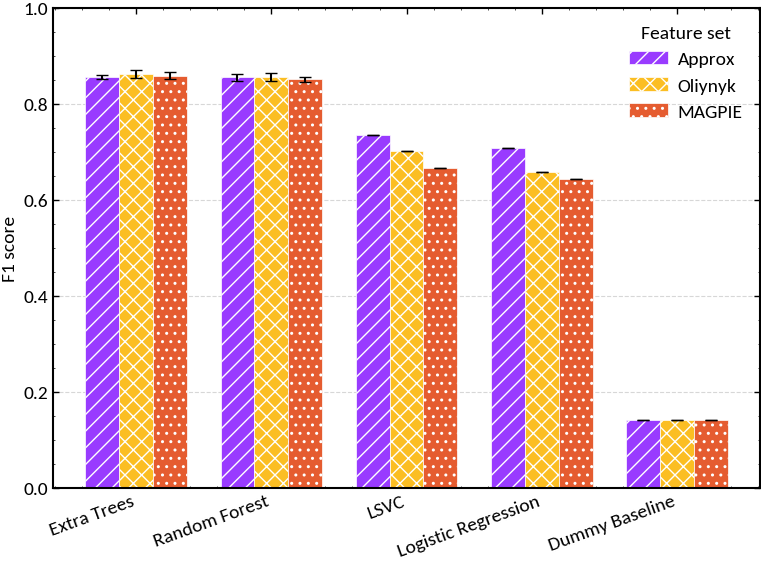

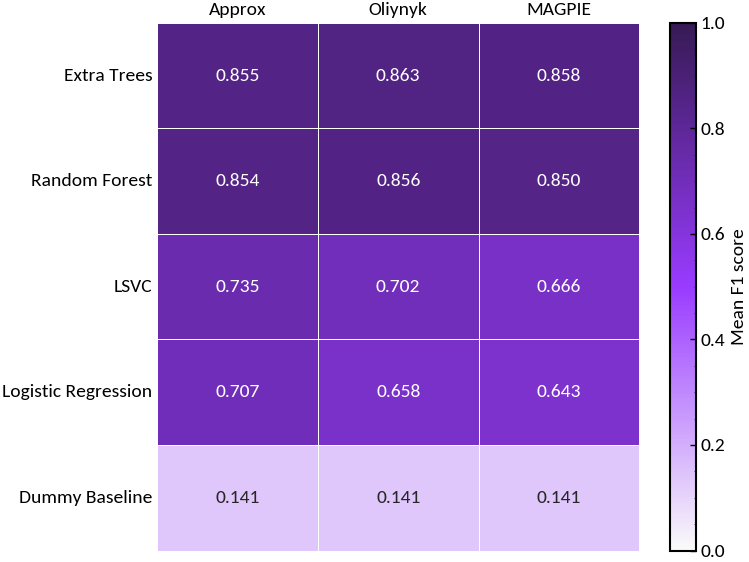

In [15]:
fig = make_bar_figure(summary)
fig.savefig('outputs/model_results_bar.png')
plt.show()

fig = make_heatmap_figure(summary)
fig.savefig('outputs/F1_score_heatmap.png')
plt.show()

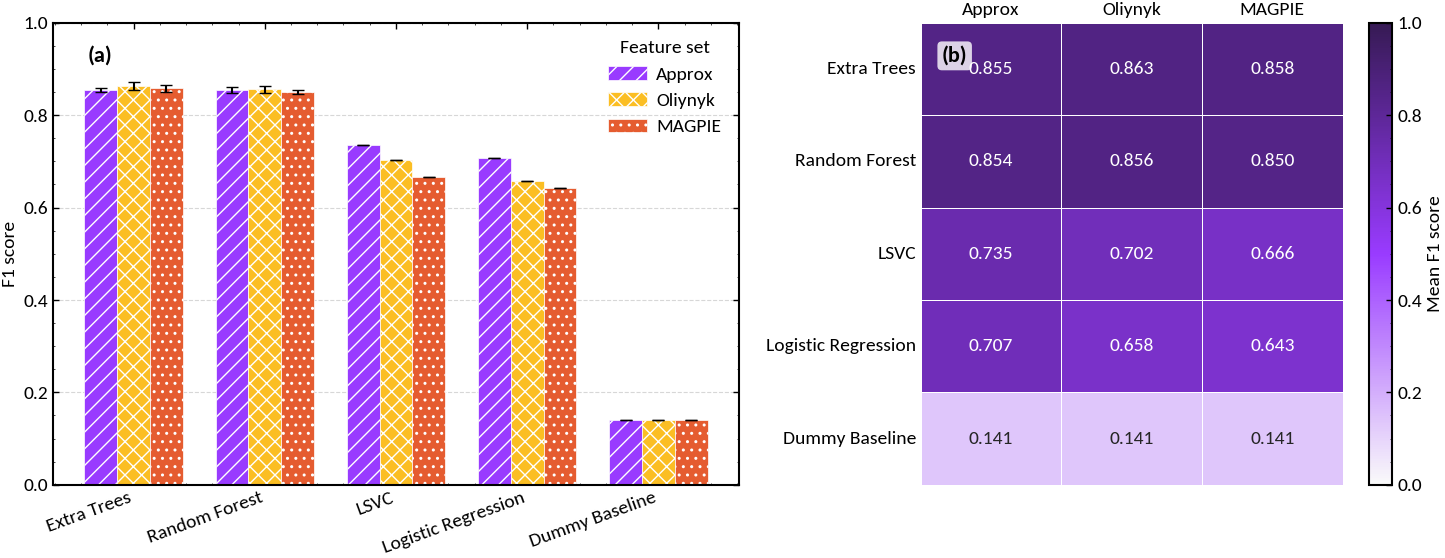

In [16]:
fig = make_combined_figure(summary)
fig.savefig('outputs/model_results.png')
plt.show()